In [1]:
import pandas as pd
import matplotlib.pyplot as plt

volume_df = pd.read_csv("europe_lng_volumes.csv")
volume_df["period"] = pd.to_datetime(volume_df["period"])

In [2]:
pre = volume_df[volume_df["period"] < "2022-02-24"]
post = volume_df[volume_df["period"] > "2022-02-24"]

print("Pre-invasion avg monthly volume (MMCF):", pre["value"].mean())
print("Post-invasion avg monthly volume (MMCF):", post["value"].mean())

Pre-invasion avg monthly volume (MMCF): 6310.597457627118
Post-invasion avg monthly volume (MMCF): 20022.96692607004


In [4]:
pre_total = pre.groupby("period")["value"].sum()
post_total = post.groupby("period")["value"].sum()

print("Pre-invasion average monthly Europe total (MMCF):", pre_total.mean())
print("Post-invasion average monthly Europe total (MMCF):", post_total.mean())

Pre-invasion average monthly Europe total (MMCF): 59572.04
Post-invasion average monthly Europe total (MMCF): 218974.5744680851


In [6]:
ratio = post_total.mean() / pre_total.mean()
change = ((post_total.mean() - pre_total.mean()) / pre_total.mean()) * 100

print(f"Increase factor: {ratio:.2f}x")
print(f"Percentage increase: {change:.1f}%")

Increase factor: 3.68x
Percentage increase: 267.6%


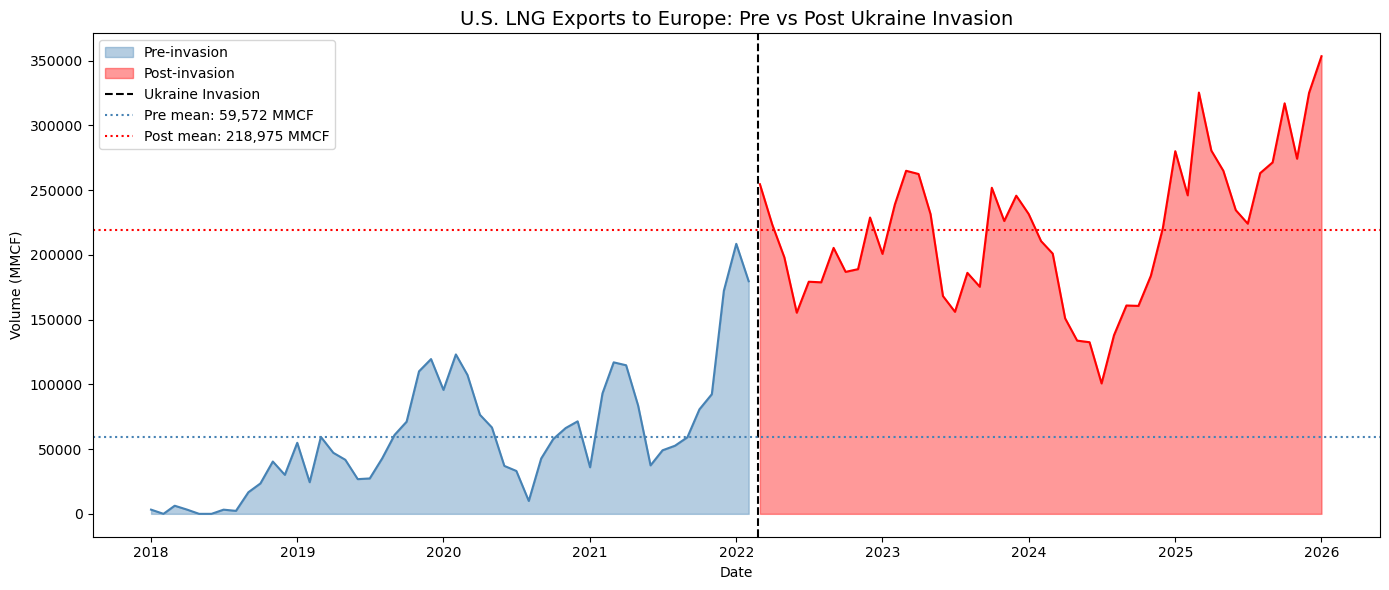

In [7]:
fig, ax = plt.subplots(figsize=(14, 6))

ax.fill_between(pre_total.index, pre_total.values,
                alpha=0.4, color="steelblue", label="Pre-invasion")
ax.plot(pre_total.index, pre_total.values,
                color="steelblue", linewidth=1.5)

ax.fill_between(post_total.index, post_total.values,
                alpha=0.4, color="red", label="Post-invasion")
ax.plot(post_total.index, post_total.values,
                color="red", linewidth=1.5)

ax.axvline(pd.Timestamp("2022-02-24"), color="black", linestyle="--", linewidth=1.5, label="Ukraine Invasion")
ax.axhline(pre_total.mean(), color="steelblue", linestyle=":", linewidth=1.5, label=f"Pre mean: {pre_total.mean():,.0f} MMCF")
ax.axhline(post_total.mean(), color="red", linestyle=":", linewidth=1.5, label=f"Post mean: {post_total.mean():,.0f} MMCF")

ax.set_title("U.S. LNG Exports to Europe: Pre vs Post Ukraine Invasion", fontsize=14)
ax.set_xlabel("Date")
ax.set_ylabel("Volume (MMCF)")
ax.legend()
plt.tight_layout()
plt.savefig("pre_post_invasion.png", dpi=150)
plt.show()

In [9]:
## Further Analysis: Seasonality-Adjusted Pre-Invasion Signal or intelligence

##Raw volumes show an anomalous winter 2021 spike relative to prior years, 
##suggesting markets may have priced in invasion risk before February 24 2022.

##Next step: calculate year-over-year volume change by month to control for 
##seasonal heating demand and isolate the geopolitical signal.